Importera paket och importera csv-filen med data till en DataFrame

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('health_study_dataset.csv')

Rensa data (Jag rensar aldrig datan eftersom jag kan se att den redan är ren)

In [2]:
# Det finns inga värden som är Na
display(df.isna().sum())
# Det finns inga dubletter
display(df.duplicated().sum())
# De numeriska kolumnerna innehåller bara floats eller ints
display(df.dtypes)
# Det finns inga extrema min eller maxvärden
display(df.describe())



id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64

np.int64(0)

id               int64
age              int64
sex             object
height         float64
weight         float64
systolic_bp    float64
cholesterol    float64
smoker          object
disease          int64
dtype: object

,id,age,height,weight,systolic_bp,cholesterol,disease
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,49.426250,171.849250,73.413000,149.178625,4.929150,0.058750
std,231.0844,14.501118,9.804259,13.685059,12.793360,0.848413,0.235303
min,1.0000,18.000000,144.400000,33.700000,106.800000,2.500000,0.000000
25%,200.7500,39.000000,164.775000,64.800000,140.900000,4.327500,0.000000
50%,400.5000,50.000000,171.350000,73.200000,149.400000,4.970000,0.000000
75%,600.2500,59.000000,178.925000,82.600000,157.600000,5.482500,0.000000
max,800.0000,90.000000,200.400000,114.400000,185.900000,7.880000,1.000000


## Beskrivande analys

Räkna ut medel, median, min och max för: age, weight, height, systolic_bp, cholesterol.

In [3]:
# Kolumner vi vill kolla på
cols = ['age', 'weight', 'height', 'systolic_bp', 'cholesterol']

# värden vi vill kolla på
funcs = ['mean', 'median', 'min', 'max']

# Enheter som kolumnerna mäts i
units = {
    'age': 'years',
    'weight': 'Kg',
    'height': 'cm',
    'systolic_bp': 'mmHg',
    'cholesterol': 'mmol',
}

# Räknar ut värdena (mean, median, min, max) på kolumnerna. avrundar till 1 decimal. .T byter på kolumn och rad
df_cols = df[cols].agg(funcs).T.round(1)

# df_cols[units] skapar en ny kolumn. .index hittar index på df_cols. .map letar upp motsvarande index från df_cols och lägger in värdet
df_cols['units'] = df_cols.index.map(units)

df_cols


,mean,median,min,max,units
age,49.4,50.0,18.0,90.0,years
weight,73.4,73.2,33.7,114.4,Kg
height,171.8,171.4,144.4,200.4,cm
systolic_bp,149.2,149.4,106.8,185.9,mmHg
cholesterol,4.9,5.0,2.5,7.9,mmol


Grafer

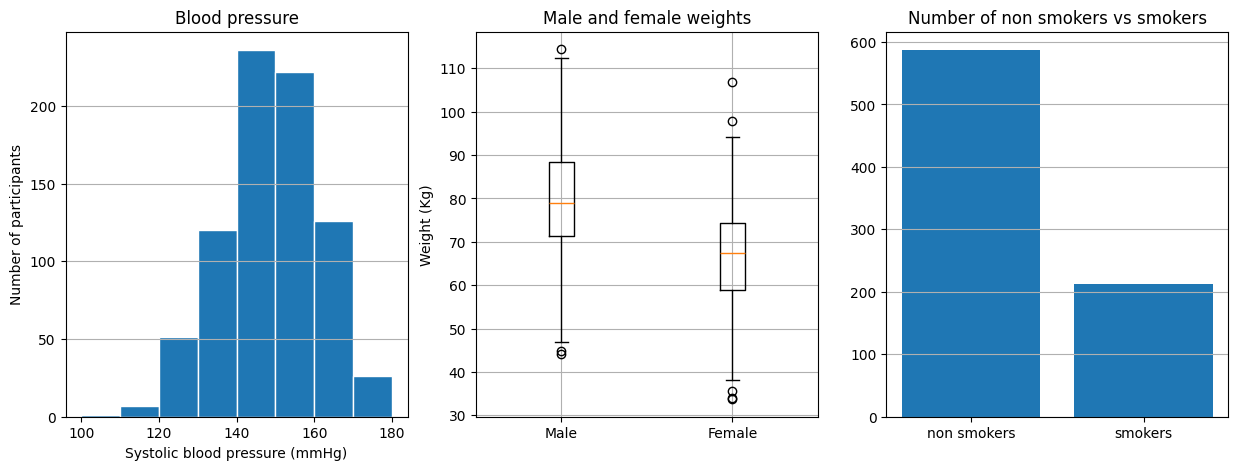

In [4]:
bins = np.arange(100, 190, 10)

fig, (ax_hist, ax_box, ax_bar) = plt.subplots(1,3, figsize=(15,5))

# histogram
ax_hist.hist(df['systolic_bp'], bins=bins, edgecolor='white')
ax_hist.set_title('Blood pressure')
ax_hist.set_xlabel('Systolic blood pressure (mmHg)')
ax_hist.set_ylabel('Number of participants')
ax_hist.grid(axis='y')

# boxplot
male_box = df[df['sex'] == 'M']['weight']
female_box = df[df['sex'] == 'F']['weight']
ax_box.boxplot([male_box, female_box], tick_labels=['Male', 'Female'])
ax_box.set_title('Male and female weights')
ax_box.grid()
ax_box.set_ylabel('Weight (Kg)')

# barchart
smoker_counts = df['smoker'].value_counts()
ax_bar.bar(['non smokers', 'smokers'], smoker_counts.values)
ax_bar.set_title('Number of non smokers vs smokers')
ax_bar.grid(axis='y')


plt.show()

## Simulering kopplad till caset 
Beräkna andelen personer i datasetet som har sjukdomen.

In [5]:
# Eftersom värdet i 'disease' är antingen 1 eller 0 så kan vi ta medelvärdet direkt för att få ut % som har sjukdomen
participants_with_disease = df['disease'].mean()

print(f'Percentage of participants with disease: {(participants_with_disease * 100).round(2)} %')

Percentage of participants with disease: 5.88 %


Använd numpy för att simulera 1000 slumpade personer med samma sannolikhet för sjukdom.

In [6]:
np.random.seed(42)

# Skapar en np.array med 1000 random rader(element) med antingen 0 eller 1.
# Sannolikhet för 0 är: 1 - populationsannolikheten (5.88%) = 94.12%. Sannolikheten för 1 är populationsannolikheten (5.88%)
# Räknar ut medelvärdet
simulated_disease = np.random.choice([0, 1], size=1000, p=[1 - participants_with_disease, participants_with_disease]).mean()

print(f'Percentage of participants with disease: {(simulated_disease * 100).round(2)} %')

Percentage of participants with disease: 5.6 %


## Konfidensintervall

Beräkna ett konfidensintervall för medelvärdet av systolic_bp (t.ex. med normalapproximation eller bootstrap, som vi gått igenom på kursen).

jag använder bootstrap då jag hittade denna video https://www.youtube.com/watch?v=TqOeMYtOc1w som enkelt förklarade hur det fungerar

In [7]:
# skapa ett frö
np.random.seed(42)

def ci_bootstrap(data, n_bootstraps=5000, confidence=0.95):
    len_data = len(data)
    # skapar en tom lista med 5000 rader
    boot_means = np.empty(n_bootstraps)
    for i in range(n_bootstraps):
        # lägger till medelvärden i listan från ett random sample. Dubletter är tillåtna
        boot_sample = np.random.choice(data, size=len_data, replace=True)
        boot_means[i] = np.mean(boot_sample)

    # ger oss 0.025 (eftersom vi vill räkna ut medelvärden som ligger inom 95 procentilen tar vi bort 2.5% i nedre och 2.5 i övre, totalt 5%.)
    alpha = (1-confidence) / 2
    # ger oss det lägsta värdet inom konfidensintervallet 95%.
    lower = np.percentile(boot_means, 100 * alpha)
    # ger oss det högsta värdet inom konfidensintervallet 95%.
    upper = np.percentile(boot_means, 100 * (1 - alpha))

    return lower, upper


lower, upper = ci_bootstrap(df['systolic_bp'])

lower, upper, np.mean(df['systolic_bp'])

(np.float64(148.31424687499998),
 np.float64(150.08714375),
 np.float64(149.178625))

Konfidensintervallet på blodtryck ligger mellan 148.31 mmHg till 150.09 mmHg i vårt urval

Medelvärdet av vårt urval (dataset/hela systolic_bp) är 149.17 mmHg och ligger alltså innanför konfidensintervallet.

Detta betyder att medelvärdet av vårt urval är en rimlig uppskattning på hela populationen.

## Hypotesprövning

Testa hypotesen: ”Rökare har högre medel-blodtryck än icke-rökare.”
Använd en av metoderna vi gått igenom (t.ex. bootstrap eller enkel t-test-funktion).
Förklara kort resultatet i en markdown-ruta.

In [13]:
import scipy.stats as stats

smokers = df[df['smoker'] == 'Yes']['systolic_bp']
non_smokers = df[df['smoker'] == 'No']['systolic_bp']

t_stat, p_value = stats.ttest_ind(smokers, non_smokers, equal_var=False)

t_stat, p_value, smokers.mean(), non_smokers.mean()

(np.float64(0.4503433193393224),
 np.float64(0.6527338743398998),
 np.float64(149.524882629108),
 np.float64(149.05298126064736))

Medelvärde på blodtryck hos rökare: 149,53 mmHg

Medelvärde på blodtryck hos ickerökare: 149,05 mmHg

Skillnad: 0.47 mmHg

p-värde: 0.65
t-värde: 0.45


Med welchmetoden antar vi att det inte finns någon statistisk signifikant skillnad i blodtryck mellan rökare och icke rökare. 

P-värdet 0.65 betyder att det finns en 65% sannolikhet att slumpen ger en skillnad minst lika stor som skillnaden mellan medelvärdena mellan grupperna rökare och ickerökare. Alltså 0.47 mmHg.
Eftersom 65% är en stor sannolikhet kan vi anta att skillnaden mycket väl kan bero på slmupen. För att skillnaden ska vara statistisk signifikant behöver P-värdet vara mindre än 0.05.

Slutsatsen är att vi utifrån vårt stickprov inte kan dra en slutstats om rökning påverkar blodtrycket eller inte för hela populationen.

